In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [71]:
# Import credit card datasaet
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


First lets undersample since this is a fraud dataset

In [72]:
X = df.drop(columns='Class')

In [73]:
y = df['Class']

In [74]:
print("Original dataset shape:", Counter(y))

Original dataset shape: Counter({0: 284315, 1: 492})


In [75]:
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Resampled dataset shape: Counter({0: 492, 1: 492})


The features are not that clear in this dataset, so we can first check for correlations in the data

<Axes: >

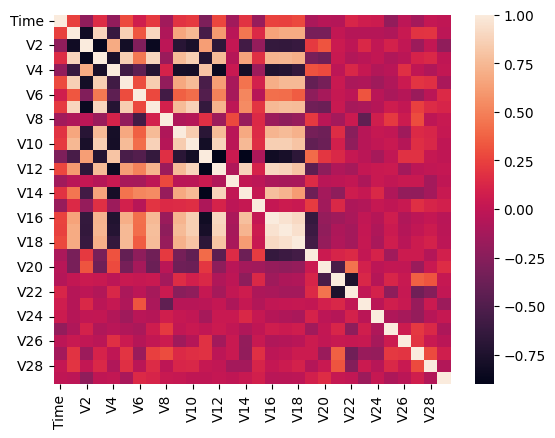

In [76]:
sns.heatmap(X_resampled.corr())

In [77]:
X = sm.add_constant(X) 
model = sm.OLS(y, X) 
results = model.fit() 
print(results.params) 

const     1.513407e-03
Time     -4.394263e-09
V1       -1.928620e-03
V2        2.869009e-03
V3       -5.094224e-03
V4        3.773967e-03
V5       -2.331491e-03
V6       -1.659706e-03
V7       -6.845068e-03
V8        8.386991e-04
V9       -3.623931e-03
V10      -8.099291e-03
V11       6.250217e-03
V12      -1.078732e-02
V13      -2.139852e-04
V14      -1.319082e-02
V15      -2.276118e-04
V16      -9.303530e-03
V17      -1.599623e-02
V18      -5.576934e-03
V19       1.905002e-03
V20       2.823245e-04
V21       2.039853e-03
V22       2.469478e-04
V23       1.605846e-04
V24      -5.158609e-04
V25       3.340582e-04
V26       3.776389e-04
V27       1.678495e-03
V28       1.138270e-03
Amount    7.138858e-06
dtype: float64


In [78]:
y_pred = results.predict(X)

Text(0, 0.5, 'Y True')

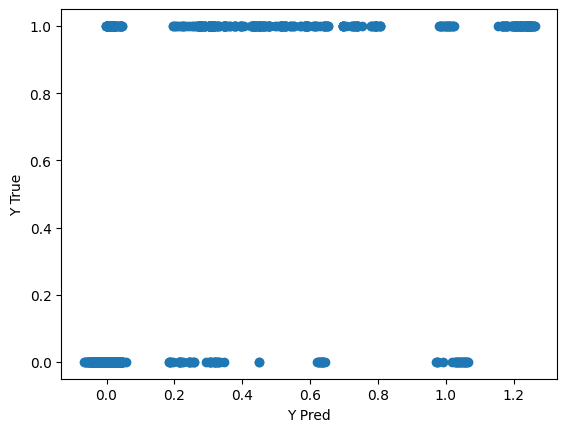

In [79]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [80]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.0033740975340107947

In [81]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [82]:
vif_data

,Feature,VIF
0,const,10.065370
1,Time,1.879865
2,V1,1.651908
3,V2,4.422390
4,V3,1.877342
5,V4,1.138061
6,V5,2.859316
7,V6,1.571530
8,V7,2.929040
9,V8,1.131633


The model overpredicts a lot of negative cases, and underpredicts a lot of positive cases. There are likely non-linear patterns in the data

There is not too much multicolinearity, aside from Amount 

Attempting Polynomial Terms

In [83]:
df_X_with_square = pd.concat((X, (X**2).rename(columns = {f"{var}": f"{var}_2" for var in X.columns})), axis = 1) 
df_X_with_square = sm.add_constant(df_X_with_square) 
model = sm.OLS(y, df_X_with_square) 
results = model.fit() 
print(results.params)

const       5.054428e-03
Time       -1.973970e-08
V1         -5.826360e-03
V2          4.481218e-03
V3         -1.236083e-02
                ...     
V25_2       9.106472e-06
V26_2       1.232904e-03
V27_2       3.494659e-05
V28_2      -2.255337e-05
Amount_2    8.350606e-10
Length: 62, dtype: float64


In [84]:
y_pred = results.predict(df_X_with_square)

Text(0, 0.5, 'Y True')

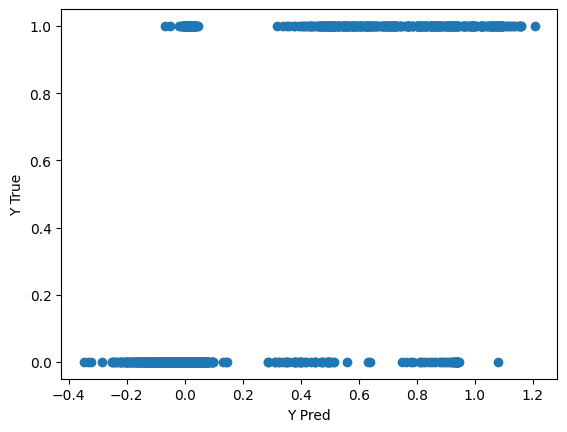

In [85]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [86]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.005065552998079394

This model is actually a bit worse

In [87]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df_X_with_square.columns
vif_data["VIF"] = [variance_inflation_factor(df_X_with_square.values, i) for i in range(df_X_with_square.shape[1])]

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [88]:
len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])

C:\Users\caleb\AppData\Local\Temp\ipykernel_28704\2692098991.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(vif_data.sort_values(by="VIF")[vif_data['VIF'] > 5])


21

21 of the features have VIF > 5, showing multicollinearity. Lets drop them

In [89]:
vif_data = vif_data[vif_data['VIF'] < 5]

In [96]:
len(vif_data['Feature'].values)

41

In [91]:
df_X_with_square_new = df_X_with_square[vif_data['Feature'].values]

In [93]:
df_X_with_square_new

,const,V4,V6,V7,V8,V9,V10,V11,V12,V13,...,V15_2,V18_2,V19_2,V22_2,V23_2,V24_2,V25_2,V26_2,V27_2,V28_2
0,1.0,1.378155,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,...,2.155544,0.000665,0.163210,0.077194,0.012204,0.004479,0.016522,0.035764,0.017838,0.000443
1,1.0,0.448154,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,...,0.403934,0.033621,0.021253,0.407902,0.010259,0.115496,0.027946,0.015849,0.000081,0.000217
2,1.0,0.379780,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,...,5.503082,0.014728,5.115998,0.595489,0.827031,0.475108,0.107349,0.019348,0.003064,0.003570
3,1.0,-0.863291,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,...,0.398689,3.864271,1.519357,0.000028,0.036222,1.381977,0.419096,0.049252,0.003934,0.003777
4,1.0,0.403034,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,...,0.030667,0.001459,0.645591,0.637249,0.018895,0.019956,0.042440,0.252297,0.048146,0.046291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.0,-2.066656,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,...,0.854624,0.260745,0.466379,0.012513,1.029169,0.259436,2.064414,0.062517,0.890478,0.678533
284803,1.0,-0.738589,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,...,1.357064,1.491278,2.388744,0.854485,0.000155,1.032715,0.367993,0.156227,0.004688,0.002865
284804,1.0,-0.557828,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,...,1.766995,0.156541,0.333220,0.334349,0.001406,0.409771,0.070621,0.007634,0.000020,0.000705
284805,1.0,0.689799,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,...,3.851654,1.240953,8.397528,0.640078,0.026666,0.015180,0.323942,0.298846,0.011842,0.010927


In [97]:
model = sm.OLS(y, df_X_with_square_new) 
results = model.fit() 
print(results.params)

const      0.000738
V4         0.003028
V6        -0.000910
V7        -0.005078
V8         0.001798
V9        -0.003900
V10       -0.007526
V11        0.004422
V12       -0.007634
V13       -0.000570
V14       -0.009517
V15       -0.000024
V16       -0.008143
V17       -0.013777
V18       -0.005379
V19        0.001576
V20        0.000024
V21        0.002189
V22        0.000093
V23       -0.000034
V24       -0.001335
V25       -0.000077
V26        0.001014
V27        0.002329
V28        0.002540
const_2    0.000738
V4_2       0.000210
V9_2       0.000590
V11_2     -0.002170
V13_2      0.000211
V14_2      0.002680
V15_2     -0.000735
V18_2     -0.001408
V19_2     -0.000110
V22_2      0.001539
V23_2      0.000019
V24_2     -0.000809
V25_2     -0.000301
V26_2     -0.000333
V27_2      0.000234
V28_2     -0.000125
dtype: float64


In [99]:
y_pred = results.predict(df_X_with_square_new)

Text(0, 0.5, 'Y True')

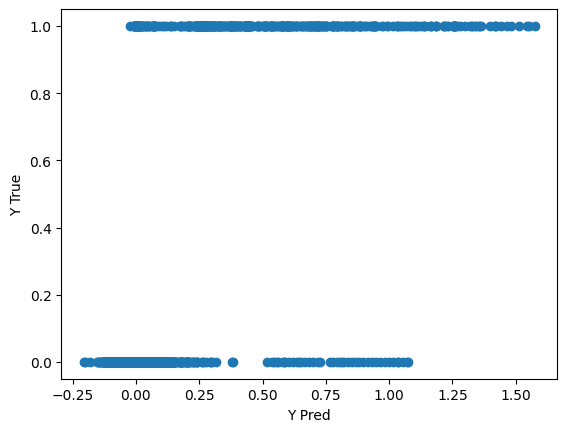

In [100]:
plt.scatter(y_pred, y)
plt.xlabel("Y Pred")
plt.ylabel("Y True")

In [101]:
mean_absolute_error(y_true=y, y_pred=y_pred)

0.006337391222183026